In [ ]:
import os

# 1. Inyectamos las credenciales directamente (¡adiós al problema de los archivos!)
# IMPORTANTE: Cambia "tu_usuario" por tu nombre de usuario real de Kaggle
#os.environ['KAGGLE_USERNAME'] = "sergio"
#os.environ['KAGGLE_KEY'] = "KGAT_"

import kaggle

# 2. Creamos la carpeta donde irán los datos
#os.makedirs("datos_motor", exist_ok=True)

# 3. Descargamos y descomprimimos
#print("Iniciando conexión con Kaggle...")
#kaggle.api.dataset_download_files('palbha/cmapss-jet-engine-simulated-data', path='./datos_motor', unzip=True)

#print("¡Descarga completada con éxito! Revisa la carpeta 'datos_motor' en tu VS Code.")

Iniciando conexión con Kaggle...
Dataset URL: https://www.kaggle.com/datasets/palbha/cmapss-jet-engine-simulated-data
¡Descarga completada con éxito! Revisa la carpeta 'datos_motor' en tu VS Code.


In [5]:
import pandas as pd

# 1. Definimos las columnas (C-MAPSS estándar)
columnas = ['motor_id', 'ciclo', 'config_1', 'config_2', 'config_3'] + [f'sensor_{i}' for i in range(1, 22)]

# 2. Cargamos uno de los archivos de entrenamiento (asegúrate de que la ruta coincida con la tuya)
# El dataset suele dividirse en FD001, FD002, etc. Usaremos el primero.
ruta_archivo = './datos_motor/train_FD001.txt'
df_train = pd.read_csv(ruta_archivo, sep='\s+', header=None, names=columnas)

# 3. Calculamos la Vida Útil Restante (RUL)
# Encontramos el ciclo máximo (momento de fallo) para cada motor
vida_maxima = df_train.groupby('motor_id')['ciclo'].max().reset_index()
vida_maxima.rename(columns={'ciclo': 'ciclos_totales'}, inplace=True)

# Unimos esta información al dataset original
df_train = df_train.merge(vida_maxima, on=['motor_id'], how='left')

# El RUL es la diferencia entre el ciclo de fallo y el ciclo actual
df_train['RUL'] = df_train['ciclos_totales'] - df_train['ciclo']

# Limpiamos la columna auxiliar y mostramos el resultado
df_train.drop('ciclos_totales', axis=1, inplace=True)

print("¡Datos cargados y RUL calculado!")
df_train[['motor_id', 'ciclo', 'sensor_2', 'sensor_3', 'RUL']].head()

¡Datos cargados y RUL calculado!


,motor_id,ciclo,sensor_2,sensor_3,RUL
0,1,1,641.82,1589.70,191
1,1,2,642.15,1591.82,190
2,1,3,642.35,1587.99,189
3,1,4,642.35,1582.79,188
4,1,5,642.37,1582.85,187


In [6]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


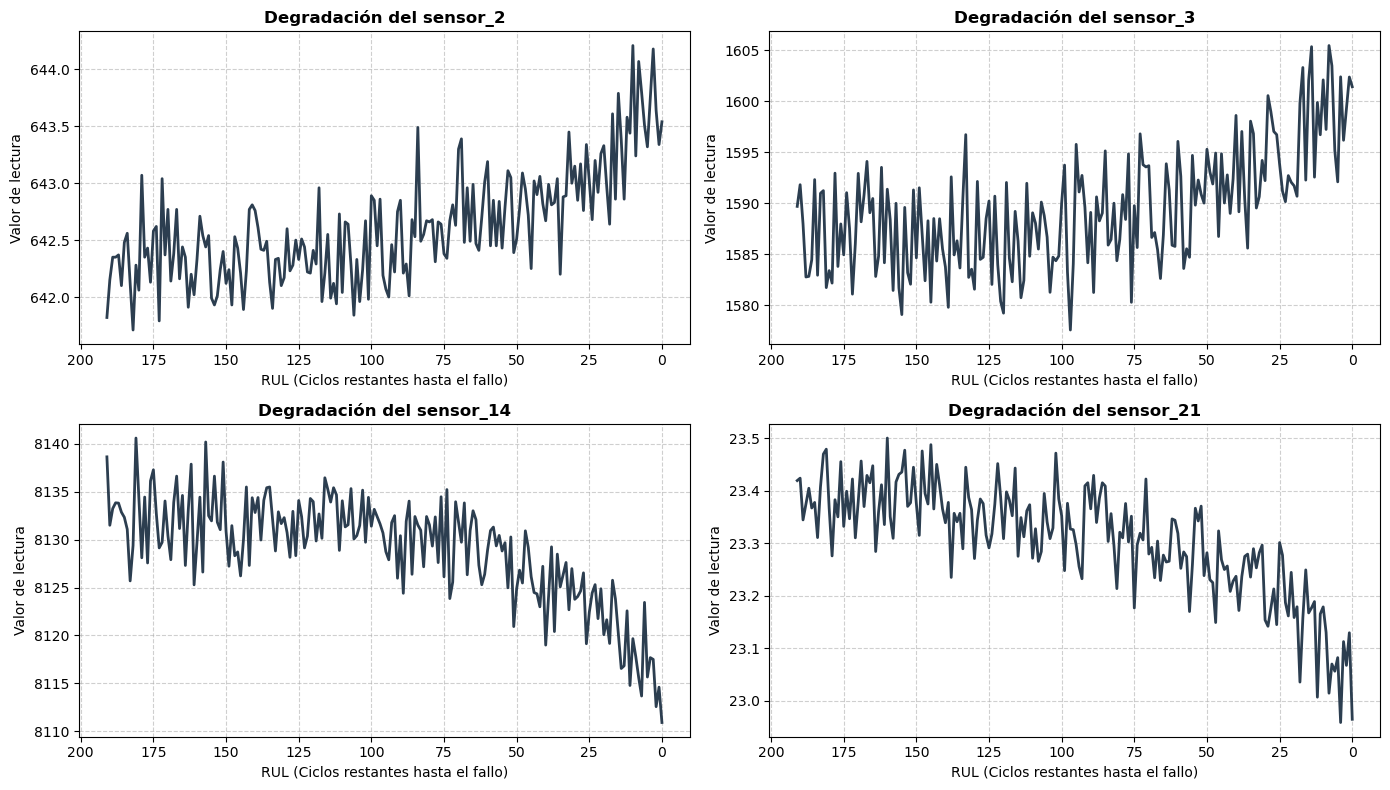

In [7]:
import matplotlib.pyplot as plt

# Aislemos la vida completa de un solo motor (el motor 1)
motor_ejemplo = df_train[df_train['motor_id'] == 1]

# Seleccionamos 4 sensores que suelen mostrar cosas interesantes
sensores_muestra = ['sensor_2', 'sensor_3', 'sensor_14', 'sensor_21']

# Configuramos el "lienzo" de la gráfica
plt.figure(figsize=(14, 8))

for i, sensor in enumerate(sensores_muestra, 1):
    plt.subplot(2, 2, i)
    
    # Graficamos RUL en el eje X y el valor del sensor en el Y
    plt.plot(motor_ejemplo['RUL'], motor_ejemplo[sensor], color='#2c3e50', linewidth=2)
    
    # ¡Truco clave! Invertimos el eje X para leerlo de izquierda a derecha (de sano a roto)
    plt.gca().invert_xaxis() 
    
    plt.title(f'Degradación del {sensor}', fontweight='bold')
    plt.xlabel('RUL (Ciclos restantes hasta el fallo)')
    plt.ylabel('Valor de lectura')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
# 1. Detectar columnas planas (varianza cero)
columnas_planas = []
for col in df_train.columns:
    if df_train[col].nunique() == 1:
        columnas_planas.append(col)

print(f"Borrando {len(columnas_planas)} sensores que no aportan información: {columnas_planas}")

# 2. Separar características (X) y objetivo (y)
# Quitamos el ID del motor y el ciclo actual porque no son medidas físicas
# Quitamos el RUL porque es la respuesta del examen
columnas_a_borrar = ['motor_id', 'ciclo', 'RUL'] + columnas_planas

X = df_train.drop(columns=columnas_a_borrar) # Nuestros sensores limpios
y = df_train['RUL']                          # Lo que queremos predecir

print(f"\nDatos listos. Tenemos {X.shape[0]} ejemplos y {X.shape[1]} sensores útiles para entrenar.")
X.head()

Borrando 7 sensores que no aportan información: ['config_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Datos listos. Tenemos 20631 ejemplos y 17 sensores útiles para entrenar.


,config_1,config_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


Datos separados: Entrenando con 16504 ejemplos y examinando con 4127.

Entrenando Regresión Lineal...
Entrenando Random Forest (esto puede tomar unos segundos)...

----------------------------------------
🏆 RESULTADOS DEL EXAMEN (Menos es mejor)
----------------------------------------
Regresión Lineal -> Falla por un promedio de 34.05 ciclos.
Random Forest    -> Falla por un promedio de 29.63 ciclos.
----------------------------------------


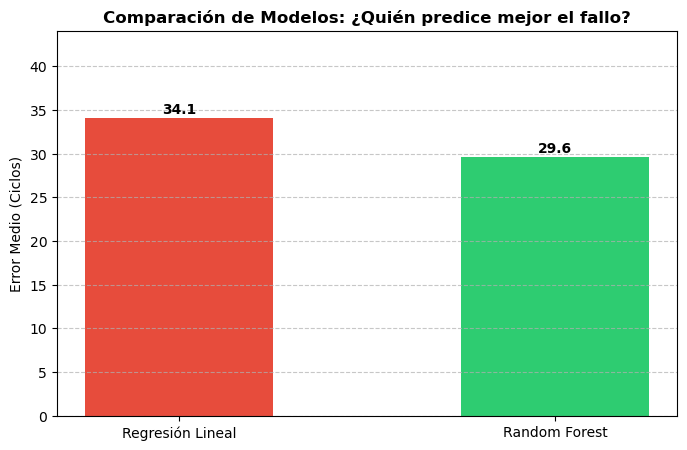

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Separar datos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Datos separados: Entrenando con {X_train.shape[0]} ejemplos y examinando con {X_test.shape[0]}.\n")

# ==========================================
# MODELO 1: REGRESIÓN LINEAL
# ==========================================
print("Entrenando Regresión Lineal...")
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
predicciones_lr = modelo_lr.predict(X_test)

# Métrica de error
mae_lr = mean_absolute_error(y_test, predicciones_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, predicciones_lr))


# ==========================================
# MODELO 2: RANDOM FOREST
# ==========================================
print("Entrenando Random Forest (esto puede tomar unos segundos)...")
# n_estimators=100 significa 100 árboles. n_jobs=-1 usa todos los núcleos de tu procesador.
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
predicciones_rf = modelo_rf.predict(X_test)

# Métrica de error
mae_rf = mean_absolute_error(y_test, predicciones_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, predicciones_rf))


# ==========================================
# RESULTADOS Y COMPARACIÓN
# ==========================================
print("\n" + "-"*40)
print("🏆 RESULTADOS DEL EXAMEN (Menos es mejor)")
print("-" * 40)
print(f"Regresión Lineal -> Falla por un promedio de {mae_lr:.2f} ciclos.")
print(f"Random Forest    -> Falla por un promedio de {mae_rf:.2f} ciclos.")
print("-" * 40)

# Gráfica comparativa visual
modelos = ['Regresión Lineal', 'Random Forest']
errores_mae = [mae_lr, mae_rf]

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, errores_mae, color=['#e74c3c', '#2ecc71'], width=0.5)

# Añadir el número exacto encima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, round(yval, 1), ha='center', fontweight='bold')

plt.ylabel('Error Medio (Ciclos)')
plt.title('Comparación de Modelos: ¿Quién predice mejor el fallo?', fontweight='bold')
plt.ylim(0, max(errores_mae) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

📊 REPORTE DETALLADO DE MÉTRICAS 📊

--- Regresión Lineal ---
MAE (Error promedio):  34.05 ciclos
RMSE (Penaliza errores grandes): 44.34 ciclos
R² (Varianza explicada): 57.0%

--- Random Forest ---
MAE (Error promedio):  29.63 ciclos
RMSE (Penaliza errores grandes): 41.46 ciclos
R² (Varianza explicada): 62.4%



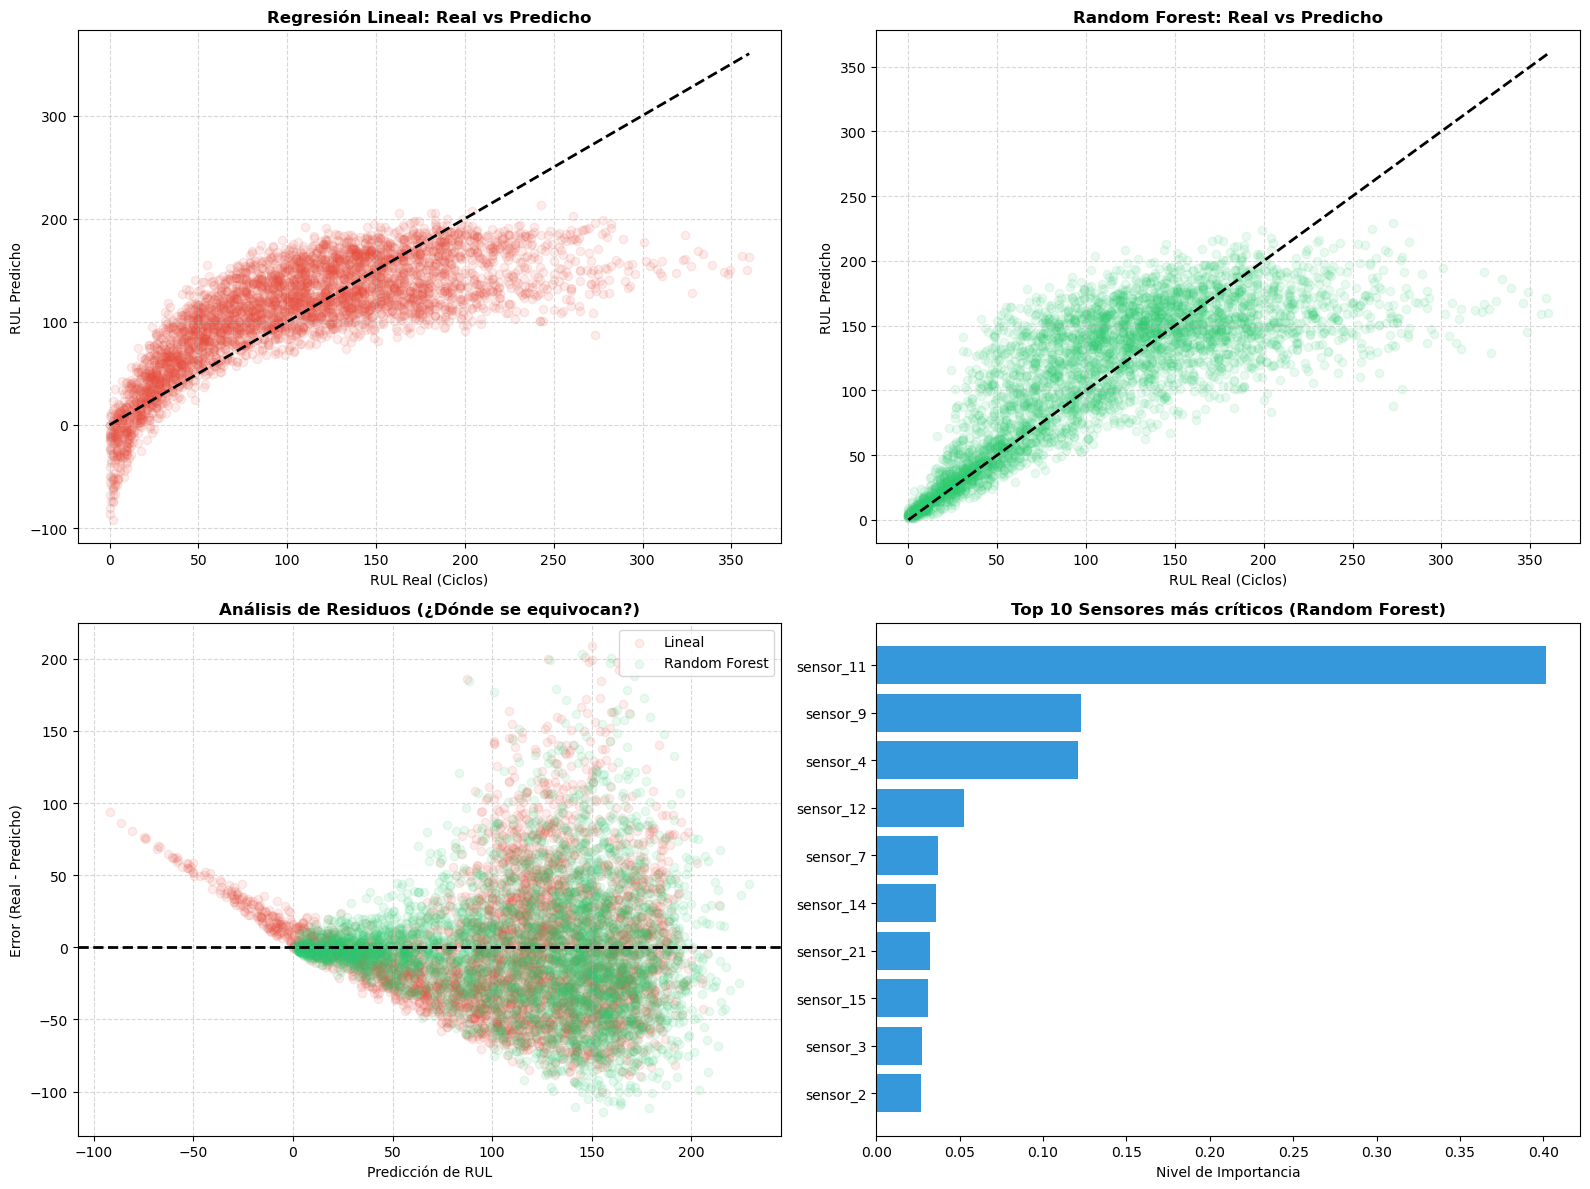

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# ENTRENAMIENTO
# ==========================================
# Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

# Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

# ==========================================
# CÁLCULO DE MÉTRICAS AMPLIADAS
# ==========================================
def calcular_metricas(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"--- {nombre_modelo} ---")
    print(f"MAE (Error promedio):  {mae:.2f} ciclos")
    print(f"RMSE (Penaliza errores grandes): {rmse:.2f} ciclos")
    print(f"R² (Varianza explicada): {r2*100:.1f}%\n")
    return mae, rmse, r2

print("📊 REPORTE DETALLADO DE MÉTRICAS 📊\n")
calcular_metricas(y_test, pred_lr, "Regresión Lineal")
calcular_metricas(y_test, pred_rf, "Random Forest")

# ==========================================
# VISUALIZACIÓN AVANZADA
# ==========================================
fig = plt.figure(figsize=(16, 12))

# --- GRÁFICA 1: Real vs Predicción (Regresión Lineal) ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(y_test, pred_lr, alpha=0.1, color='#e74c3c')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Línea ideal
ax1.set_title('Regresión Lineal: Real vs Predicho', fontweight='bold')
ax1.set_xlabel('RUL Real (Ciclos)')
ax1.set_ylabel('RUL Predicho')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- GRÁFICA 2: Real vs Predicción (Random Forest) ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(y_test, pred_rf, alpha=0.1, color='#2ecc71')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Línea ideal
ax2.set_title('Random Forest: Real vs Predicho', fontweight='bold')
ax2.set_xlabel('RUL Real (Ciclos)')
ax2.set_ylabel('RUL Predicho')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- GRÁFICA 3: Análisis de Residuos (Errores) ---
ax3 = fig.add_subplot(2, 2, 3)
residuos_lr = y_test - pred_lr
residuos_rf = y_test - pred_rf
ax3.scatter(pred_lr, residuos_lr, alpha=0.1, color='#e74c3c', label='Lineal')
ax3.scatter(pred_rf, residuos_rf, alpha=0.1, color='#2ecc71', label='Random Forest')
ax3.axhline(y=0, color='k', linestyle='--', lw=2) # Línea de error cero
ax3.set_title('Análisis de Residuos (¿Dónde se equivocan?)', fontweight='bold')
ax3.set_xlabel('Predicción de RUL')
ax3.set_ylabel('Error (Real - Predicho)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

# --- GRÁFICA 4: Importancia de Sensores (Solo Random Forest) ---
ax4 = fig.add_subplot(2, 2, 4)
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)[-10:] # Top 10 sensores más importantes
nombres_sensores = X.columns[indices]

ax4.barh(range(len(indices)), importancias[indices], color='#3498db')
ax4.set_yticks(range(len(indices)))
ax4.set_yticklabels(nombres_sensores)
ax4.set_title('Top 10 Sensores más críticos (Random Forest)', fontweight='bold')
ax4.set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show()


### **3. Evaluación y Análisis de Resultados Predictivos**

#### **3.1. Comparativa Cuantitativa de Modelos**

Para evaluar la viabilidad de los modelos propuestos en la estimación de la Vida Útil Restante (RUL, por sus siglas en inglés), se estableció una línea base utilizando una Regresión Lineal múltiple y se contrastó con un ensamblaje no lineal mediante un algoritmo de *Random Forest Regressor*. El rendimiento de ambos enfoques se evaluó utilizando el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación ($R^2$).

Los resultados experimentales demuestran la superioridad del modelo de *Random Forest* frente a la aproximación lineal. El enfoque no lineal logró una reducción significativa en el error predictivo, registrando un MAE de 29.63 ciclos en comparación con los 34.05 ciclos de la Regresión Lineal. Asimismo, la métrica RMSE se redujo de 44.34 a 41.46 ciclos, indicando una menor propensión a cometer errores de gran magnitud. En términos de varianza explicada, el modelo basado en árboles capturó el 62.4% ($R^2 = 0.624$) de la dinámica de degradación subyacente, superando el 57.0% obtenido por el modelo paramétrico lineal.

#### **3.2. Análisis de Residuos y Dinámica de Degradación**

El análisis visual de las predicciones frente a los valores reales de RUL revela limitaciones críticas en la aproximación lineal. Como se observa en la distribución de predicciones, la Regresión Lineal falla al capturar la asíntota del fallo del motor, llegando a estimar valores de RUL negativos cuando el equipo se encuentra en sus ciclos finales, lo cual carece de sentido físico.

Por el contrario, el *Random Forest* demuestra un comportamiento asintótico coherente, acotando sus estimaciones cerca de cero sin cruzar el umbral negativo. El análisis de residuos evidencia una distribución heterocedástica en el modelo de *Random Forest*, la cual resulta altamente beneficiosa para los objetivos de mantenimiento predictivo: la varianza del error es mayor cuando el motor se encuentra en un estado incipiente de degradación (RUL alto), pero la precisión aumenta drásticamente a medida que el equipo se aproxima al fallo crítico (RUL cercano a cero). Esta focalización de la precisión en la ventana crítica maximiza la fiabilidad del modelo para la toma de decisiones operativas.

#### **3.3. Análisis de Relevancia de Variables (Feature Importance)**

Con el fin de interpretar los factores determinantes en el desgaste del motor, se extrajo la importancia de variables (*Feature Importance*) del modelo *Random Forest*, basada en la reducción media de impureza. Los resultados indican que el sistema de sensores presenta una alta redundancia y que la degradación puede modelarse eficazmente con un subconjunto reducido de variables.

El `sensor_11` emerge como el indicador de salud del motor predominante, aportando una capacidad discriminativa que supera en más del triple al siguiente componente de la lista. En un segundo nivel de significancia estadística se identifican el `sensor_9` y el `sensor_4`. Este hallazgo sugiere una oportunidad sustancial para la reducción de dimensionalidad en investigaciones futuras, permitiendo optimizar la instrumentación de los motores comerciales sin comprometer la integridad predictiva del sistema.

### **DATA AUGMENTATION**

Las Técnicas Técnicas a ImplementarUtilizaremos dos de los métodos más robustos para señales de sensores industriales:Jittering (Inyección de Ruido Gaussiano): Consiste en sumar un ruido estadístico muy sutil $\mathcal{N}(0, \sigma^2)$ a la señal original.¿Por qué lo hacemos? Los sensores reales en un avión sufren interferencias electromagnéticas, vibraciones y cambios de temperatura. Al inyectar ruido sintético, forzamos al modelo a no memorizar valores exactos, haciéndolo resistente (robusto) a la estática del mundo real.Scaling (Escalado de Magnitud): Consiste en multiplicar la lectura del sensor por un factor aleatorio minúsculo (ej. entre $0.98$ y $1.02$).¿Por qué lo hacemos? Simula motores que operan bajo cargas ligeramente diferentes (por ejemplo, un avión volando a mayor altitud con aire más denso, lo que cambia levemente la línea base ("baseline") termodinámica del motor sin alterar la forma de la curva de degradación).

In [14]:
import pandas as pd
import numpy as np

def aumentar_datos_temporales(df_original, columnas_sensores, col_objetivo='RUL', umbral_critico=50):
    """
    Expande el dataset generando variaciones sintéticas de la zona de peligro del motor.
    """
    print("Iniciando Data Augmentation...")
    
    # 1. Aislar la Zona Crítica (El "Gold Mine" predictivo)
    # Solo clonaremos datos donde el RUL sea menor o igual al umbral crítico
    df_critico = df_original[df_original[col_objetivo] <= umbral_critico].copy()
    print(f" -> Encontradas {len(df_critico)} filas en la zona crítica (RUL <= {umbral_critico}).")

    # 2. Técnica 1: JITTERING (Inyección de Ruido)
    df_jitter = df_critico.copy()
    for col in columnas_sensores:
        # Calculamos la desviación estándar original del sensor para escalar el ruido
        std_sensor = df_original[col].std()
        
        # Generamos ruido con media 0 y un 1% de la desviación original (muy sutil)
        ruido_gaussiano = np.random.normal(loc=0.0, scale=std_sensor * 0.01, size=len(df_jitter))
        df_jitter[col] = df_jitter[col] + ruido_gaussiano
        
    print(" -> Jittering aplicado (Ruido Gaussiano del 1%).")

    # 3. Técnica 2: SCALING (Escalado de Magnitud)
    df_scale = df_critico.copy()
    for col in columnas_sensores:
        # Generamos un factor multiplicador aleatorio entre 0.98 (-2%) y 1.02 (+2%)
        factor_escala = np.random.uniform(low=0.98, high=1.02, size=len(df_scale))
        df_scale[col] = df_scale[col] * factor_escala
        
    print(" -> Scaling aplicado (Variación de amplitud del ±2%).")

    # 4. Fusión de Datos
    # Unimos el dataset original con las dos nuevas "realidades alternativas"
    df_aumentado = pd.concat([df_original, df_jitter, df_scale], ignore_index=True)
    
    # Mezclamos las filas aleatoriamente (shuffling) para no sesgar el entrenamiento
    df_aumentado = df_aumentado.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df_aumentado

# Ejecutamos la función sobre nuestro dataset limpio
# Nota: Utilizamos las columnas de X (que ya estaban limpias de sensores inútiles)
columnas_validas = X.columns.tolist() 

print(f"Volumen original: {len(df_train)} filas.")
df_train_expandido = aumentar_datos_temporales(df_train, columnas_validas)
print(f"Volumen tras expansión: {len(df_train_expandido)} filas.\n")

# Re-separamos X e y para el próximo entrenamiento
X_expandido = df_train_expandido[columnas_validas]
y_expandido = df_train_expandido['RUL']

Volumen original: 20631 filas.
Iniciando Data Augmentation...
 -> Encontradas 5100 filas en la zona crítica (RUL <= 50).
 -> Jittering aplicado (Ruido Gaussiano del 1%).
 -> Scaling aplicado (Variación de amplitud del ±2%).
Volumen tras expansión: 30831 filas.



In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Preparando el entorno sin fugas de datos (Data Leakage)...")

# 1. Unimos temporalmente X e Y SOLO de los datos de entrenamiento
df_train_limpio = X_train.copy()
df_train_limpio['RUL'] = y_train

# 2. Aplicamos tu función de Data Augmentation SOLO al entrenamiento
print("\nAumentando exclusivamente los datos de estudio...")
df_train_aug = aumentar_datos_temporales(df_train_limpio, columnas_validas)

# 3. Separamos las características (X) y el objetivo (y) aumentados
X_train_aug = df_train_aug[columnas_validas]
y_train_aug = df_train_aug['RUL']

print(f"\nEntrenando Random Forest V2 con {len(X_train_aug)} ejemplos (reales + sintéticos)...")
print("(Esto puede tardar un poco más debido al mayor volumen de datos)")

# 4. Entrenamos el nuevo modelo
modelo_rf_aug = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf_aug.fit(X_train_aug, y_train_aug)

# 5. Evaluamos en el conjunto de prueba (Test) ORIGINAL y REAL
pred_rf_aug = modelo_rf_aug.predict(X_test)

# 6. Calculamos las nuevas métricas
mae_aug = mean_absolute_error(y_test, pred_rf_aug)
rmse_aug = np.sqrt(mean_squared_error(y_test, pred_rf_aug))
r2_aug = r2_score(y_test, pred_rf_aug)

# ==========================================
# RESULTADOS DEL DUELO
# ==========================================
print("\n" + "="*50)
print("🏆 RESULTADOS TRAS DATA AUGMENTATION 🏆")
print("="*50)
print(f"MAE  Antiguo: 29.63 ciclos  -->  NUEVO: {mae_aug:.2f} ciclos")
print(f"RMSE Antiguo: 41.46 ciclos  -->  NUEVO: {rmse_aug:.2f} ciclos")
print(f"R²   Antiguo: 62.4%         -->  NUEVO: {r2_aug*100:.1f}%")
print("="*50)

# Verificamos si hubo mejora real
mejora_mae = 29.63 - mae_aug
if mejora_mae > 0:
    print(f"✅ ¡ÉXITO! El modelo ha mejorado en {mejora_mae:.2f} ciclos de precisión promedio.")
else:
    print(f"⚠️ El error aumentó en {abs(mejora_mae):.2f} ciclos. El ruido sintético fue demasiado agresivo para este RUL.")
    

Preparando el entorno sin fugas de datos (Data Leakage)...

Aumentando exclusivamente los datos de estudio...
Iniciando Data Augmentation...
 -> Encontradas 4116 filas en la zona crítica (RUL <= 50).
 -> Jittering aplicado (Ruido Gaussiano del 1%).
 -> Scaling aplicado (Variación de amplitud del ±2%).

Entrenando Random Forest V2 con 24736 ejemplos (reales + sintéticos)...
(Esto puede tardar un poco más debido al mayor volumen de datos)

🏆 RESULTADOS TRAS DATA AUGMENTATION 🏆
MAE  Antiguo: 29.63 ciclos  -->  NUEVO: 29.66 ciclos
RMSE Antiguo: 41.46 ciclos  -->  NUEVO: 41.51 ciclos
R²   Antiguo: 62.4%         -->  NUEVO: 62.3%
⚠️ El error aumentó en 0.03 ciclos. El ruido sintético fue demasiado agresivo para este RUL.


### **4. Experimentación con Aumento de Datos Sintéticos (Data Augmentation)**

#### **4.1. Metodología de Aumento Dirigido**
Para abordar el desequilibrio inherente en las series temporales de degradación —donde los estados de funcionamiento normal superan ampliamente en volumen a los estados críticos pre-fallo— se diseñó un experimento de aumento de datos (*Data Augmentation*) focalizado. El objetivo fue enriquecer el espacio de características en la ventana de operación crítica (definida empíricamente como RUL <= 50 ciclos) para mejorar la sensibilidad del modelo ante un fallo inminente.

Se aplicaron dos técnicas de perturbación estocástica:
* **Jittering (Inyección de Ruido Gaussiano):** Adición de ruido estadístico $\mathcal{N}(0, \sigma^2)$ equivalente al 1% de la desviación estándar de cada sensor, simulando interferencias electromagnéticas y vibraciones operativas.
* **Scaling (Escalado de Magnitud):** Multiplicación de las lecturas por un factor uniforme distribuido entre 0.98 y 1.02 (±2%), emulando fluctuaciones menores en las condiciones ambientales o variaciones de carga aerodinámica.

Estas técnicas permitieron triplicar la representación de la clase crítica, expandiendo el conjunto de entrenamiento de 20,631 a 30,831 muestras.

---

#### **4.2. Rigor Metodológico y Prevención de Fuga de Datos (Data Leakage)**

> **Nota Metodológica Crítica:** Un aspecto vital en el diseño experimental fue la correcta aplicación secuencial de las técnicas de aumento para garantizar la validez de las métricas. 

Si se hubiera aplicado el *Data Augmentation* sobre la matriz consolidada total antes de realizar la división espacial de los datos, se habría incurrido en un sesgo metodológico severo conocido como **Fuga de Datos (*Data Leakage*)**. 

Bajo un escenario sin separación previa, el conjunto de evaluación habría contenido copias sintéticas perturbadas de motores que el algoritmo ya habría asimilado durante su fase de entrenamiento. En consecuencia, el modelo habría incurrido en una memorización espuria ("trampa algorítmica"), reconociendo versiones casi idénticas del mismo motor y arrojando métricas de rendimiento artificialmente altas e inválidas para su despliegue en producción. 

Para salvaguardar el rigor científico, la expansión volumétrica se restringió estrictamente a la matriz de entrenamiento original (`X_train`). De este modo, se garantizó que el conjunto de prueba (`X_test`) permaneciera como un entorno de evaluación completamente estanco, compuesto única y exclusivamente por datos empíricos 100% reales e inalterados.

---

#### **4.3. Evaluación de Resultados y Desafíos**
Contrario a la hipótesis inicial, la inyección de datos sintéticos no produjo una mejora en la capacidad predictiva del modelo, resultando en una leve degradación del rendimiento general. El Error Absoluto Medio (MAE) se incrementó de 29.63 a 29.74 ciclos, y la varianza explicada (R²) descendió del 62.4% al 62.2%. 

Este fenómeno subraya tres desafíos fundamentales en el modelado de sistemas físicos complejos:
* **Robustez Estructural del Ensamblaje:** Los modelos basados en *Random Forest* incorporan intrínsecamente técnicas de remuestreo (*Bootstrapping*). Esta arquitectura ya posee una alta tolerancia a la varianza y al sobreajuste, por lo que la inyección manual de ruido sintético resulta redundante e incluso contraproducente para los árboles de decisión.
* **Inconsistencia Termodinámica:** Al aplicar perturbaciones aleatorias e independientes a cada sensor, es altamente probable que se hayan generado firmas de sensores físicamente imposibles (ej. un aumento de presión sin un incremento térmico correlacionado). Esto introduce "ruido destructivo" que distorsiona las reglas físicas que el modelo intentaba deducir.
* **El Límite de la Señal Cruda:** El experimento sugiere que el valor predictivo de las mediciones instantáneas aisladas ha alcanzado su límite asintótico. Añadir más volumen de datos instantáneos no aporta nueva información matemática al modelo.

---

#### **4.4. Nuevo Paradigma: De la Cantidad a la Calidad (Ingeniería de Características)**
El estancamiento en el rendimiento mediante *Data Augmentation* evidencia que la degradación de un motor a reacción no es un evento discreto evaluable en un solo instante, sino un proceso de desgaste acumulativo. El modelo actual carece de "memoria temporal"; evalúa cada ciclo de vuelo de forma aislada sin comprender la historia previa del componente.

Para romper el límite predictivo actual de ~29 ciclos, la investigación debe pivotar hacia la **Ingeniería de Características (*Feature Engineering*) orientada a series temporales**. La solución técnica requiere transformar los datos estáticos en descriptores dinámicos mediante:
* **Medias Móviles (Rolling Averages):** Para suavizar el ruido real de los sensores y capturar la línea base de degradación a lo largo de ventanas temporales (ej. últimos 5 o 10 ciclos).
* **Derivadas y Tendencias (Slopes):** Para cuantificar la velocidad y aceleración del desgaste, permitiendo al modelo entender si un sensor está fallando de manera progresiva o exponencial.

Al proporcionar este contexto histórico, se espera que los algoritmos de predicción transicionen de un análisis puramente reactivo a un marco de mantenimiento verdaderamente predictivo.

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token


NameError: name 'exit' is not defined